In [1]:
print('Hello world')

Hello world


In [15]:
# importing important modelling and basic libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import r2_score,mean_squared_error,mean_absolute_error
from sklearn.neighbors import KNeighborsRegressor
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression,Ridge,Lasso
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor,AdaBoostRegressor
from sklearn.svm import SVR
from sklearn.model_selection import RandomizedSearchCV
from catboost import CatBoostRegressor
from xgboost import XGBRegressor
import warnings

In [3]:
df = pd.read_csv('data/stud.csv')
df.head(2)

,gender,race_ethnicity,parental_level_of_education,lunch,test_preparation_course,math_score,reading_score,writing_score
0,female,group B,bachelor's degree,standard,none,72,72,74
1,female,group C,some college,standard,completed,69,90,88


In [4]:
## creating dependent features and independent features
X = df.drop(columns='math_score')
X

,gender,race_ethnicity,parental_level_of_education,lunch,test_preparation_course,reading_score,writing_score
0,female,group B,bachelor's degree,standard,none,72,74
1,female,group C,some college,standard,completed,90,88
2,female,group B,master's degree,standard,none,95,93
3,male,group A,associate's degree,free/reduced,none,57,44
4,male,group C,some college,standard,none,78,75
...,...,...,...,...,...,...,...
995,female,group E,master's degree,standard,completed,99,95
996,male,group C,high school,free/reduced,none,55,55
997,female,group C,high school,free/reduced,completed,71,65
998,female,group D,some college,standard,completed,78,77


In [5]:
y = df['math_score']
y

0      72
1      69
2      90
3      47
4      76
       ..
995    88
996    62
997    59
998    68
999    77
Name: math_score, Length: 1000, dtype: int64

In [6]:
#exploring the data
print("categories in 'gender' variable :  ", end=' ')
print(df['gender'].unique())

print("categories in 'race_ethnicity' variable :  ", end=' ')
print(df['race_ethnicity'].unique())

print("categories in 'parental_level_of_education' variable :  ", end=' ')
print(df['parental_level_of_education'].unique())

print("categories in 'lunch' variable :  ", end=' ')
print(df['lunch'].unique())

print("categories in 'test_preparation_course' variable :  ", end=' ')
print(df['test_preparation_course'].unique())


categories in 'gender' variable :   <StringArray>
['female', 'male']
Length: 2, dtype: str
categories in 'race_ethnicity' variable :   <StringArray>
['group B', 'group C', 'group A', 'group D', 'group E']
Length: 5, dtype: str
categories in 'parental_level_of_education' variable :   <StringArray>
[ 'bachelor's degree',       'some college',    'master's degree',
 'associate's degree',        'high school',   'some high school']
Length: 6, dtype: str
categories in 'lunch' variable :   <StringArray>
['standard', 'free/reduced']
Length: 2, dtype: str
categories in 'test_preparation_course' variable :   <StringArray>
['none', 'completed']
Length: 2, dtype: str


In [7]:
# Create Column Transformer with 3 types of transformers
num_features = X.select_dtypes(exclude="str").columns
cat_features = X.select_dtypes(include="str").columns

from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer

numeric_transformer = StandardScaler()
oh_transformer = OneHotEncoder()

preprocessor = ColumnTransformer(
    [
        ("OneHotEncoder", oh_transformer, cat_features),
         ("StandardScaler", numeric_transformer, num_features),        
    ]
)

In [8]:
X = preprocessor.fit_transform(X)

In [11]:
X.shape

(1000, 19)

In [14]:
X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.2,random_state=42)
X_train.shape

(800, 19)

In [16]:
# evaluation matrix function
def evealuate_model(true,predicted):
    r2_square = r2_score(true,predicted)
    mse = mean_squared_error(true,predicted)
    mae = mean_absolute_error(true,predicted)
    rmse = np.sqrt(r2_square)
    return r2_square,mse,mae,rmse

In [40]:
## training different models
models ={
    'linear_regression':LinearRegression(),
    'lasso':Lasso(),
    'Ridge':Ridge(),
    'KNeighborsRegressor':KNeighborsRegressor(),
    'DecisionTreeRegressor':DecisionTreeRegressor(),
    'AdaBoostRegressor': AdaBoostRegressor(),
    'RandomForestRegressor': RandomForestRegressor(),
    'XGBRegressor': XGBRegressor(),
    'Catboost':CatBoostRegressor()
}
model_list =[]
r2_score_list =[]
for i in range(len(list(models))):
    model = list(models.values())[i]
    model.fit(X_train,y_train) #fitting to model

    # prediction time
    y_train_pred = model.predict(X_train)
    y_test_pred = model.predict(X_test)

    # evaluation of predicted values
    model_train_r2_square, model_train_mse, model_train_mae, model_train_rmse = evealuate_model(y_train,y_train_pred)
    model_test_r2_square, model_test_mse, model_test_mae, model_test_rmse = evealuate_model(y_test,y_test_pred)


    print(list(models.keys())[i])
    model_list.append(list(models.keys())[i])
    print('Model performance on training dataset')
    print("- Root Mean Squared Error: {:.4f}".format(model_train_rmse))
    print("- Mean Absolute Error: {:.4f}".format(model_train_mae))
    print("- R2 Score: {:.4f}".format(model_train_r2_square))
    print('--------------------------------------')
    print('Model performance on test dataset')
    print("- Root Mean Squared Error: {:.4f}".format(model_test_rmse))
    print("- Mean Absolute Error: {:.4f}".format(model_test_mae))
    print("- R2 Score: {:.4f}".format(model_test_r2_square))
    r2_score_list.append(model_test_r2_square)
    print('='*35)
    print('\n')



linear_regression
Model performance on training dataset
- Root Mean Squared Error: 0.9350
- Mean Absolute Error: 4.2667
- R2 Score: 0.8743
--------------------------------------
Model performance on test dataset
- Root Mean Squared Error: 0.9383
- Mean Absolute Error: 4.2148
- R2 Score: 0.8804


lasso
Model performance on training dataset
- Root Mean Squared Error: 0.8984
- Mean Absolute Error: 5.2063
- R2 Score: 0.8071
--------------------------------------
Model performance on test dataset
- Root Mean Squared Error: 0.9085
- Mean Absolute Error: 5.1579
- R2 Score: 0.8253


Ridge
Model performance on training dataset
- Root Mean Squared Error: 0.9350
- Mean Absolute Error: 4.2650
- R2 Score: 0.8743
--------------------------------------
Model performance on test dataset
- Root Mean Squared Error: 0.9384
- Mean Absolute Error: 4.2111
- R2 Score: 0.8806


KNeighborsRegressor
Model performance on training dataset
- Root Mean Squared Error: 0.9249
- Mean Absolute Error: 4.5167
- R2 Score:

In [ ]:
pd.DataFrame(list(zip(model_list, r2_score_list)), columns=['Model Name', 'R2_Score']).sort_values(by=["R2_Score"],ascending=False)

['linear_regression', 'lasso', 'Ridge', 'KNeighborsRegressor', 'DecisionTreeRegressor', 'AdaBoostRegressor', 'RandomForestRegressor', 'XGBRegressor', 'Catboost']


,Model Name,R2_Score
2,Ridge,0.880593
0,linear_regression,0.880433
6,RandomForestRegressor,0.852511
8,Catboost,0.851632
5,AdaBoostRegressor,0.845410
7,XGBRegressor,0.827797
1,lasso,0.825320
3,KNeighborsRegressor,0.783813
4,DecisionTreeRegressor,0.759615


In [42]:
# best model for this dataset is Linear regression
linear_regression = LinearRegression(fit_intercept=True)
linear_regression.fit(X_train,y_train)
y_pred = linear_regression.predict(X_test)
score = r2_score(y_test,y_pred)*100
print(f'accuracy is {score}')

accuracy is 88.04332983749565


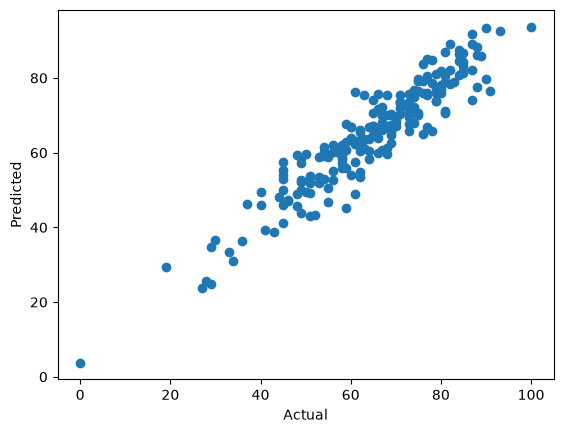

In [43]:
plt.scatter(y_test,y_pred);
plt.xlabel('Actual');
plt.ylabel('Predicted');

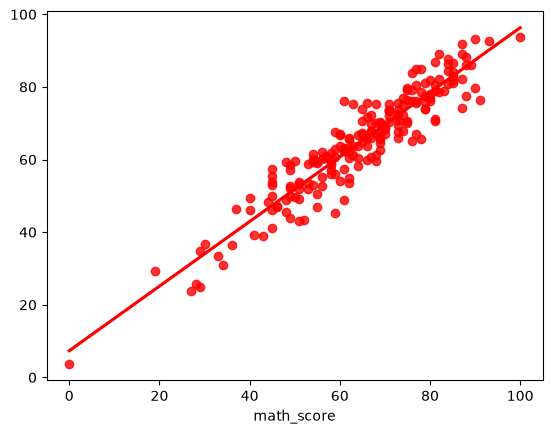

In [44]:
sns.regplot(x=y_test,y=y_pred,ci=None,color ='red');

In [46]:
# Difference between actual and predicted
pred_df=pd.DataFrame({'Actual Value':y_test,'Predicted Value':y_pred,'Difference':y_test-y_pred})
pred_df

,Actual Value,Predicted Value,Difference
521,91,76.387970,14.612030
737,53,58.885970,-5.885970
740,80,76.990265,3.009735
660,74,76.851804,-2.851804
411,84,87.627378,-3.627378
...,...,...,...
408,52,43.409149,8.590851
332,62,62.152214,-0.152214
208,74,67.888395,6.111605
613,65,67.022287,-2.022287
